# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Redmar van Sinderen
* Username: risinderen
* Student number: S6446248
* Group (AS1, etc.): As 1

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

$$\Delta g = \sqrt{(\frac{4\pi^2}{T^2}\Delta L)^2+(\frac{-8\pi^2L}{T^3}\Delta T)^2}$$

In [2]:
import numpy as np

L = 1.00
delL = 0.01
T = 2.01
delT = 0.02
g = (4*np.pi**2*L)/T**2
delg = (((4*np.pi**2)/(T**2)*delL)**2+((-8*np.pi**2*L)/(T**3)*delT)**2)**0.5
print(f"the value of g is {g}")
print(f"the error in g is {delg}")


the value of g is 9.77164367326488
the error in g is 0.2176313753358241


In [3]:
import numpy as np



Lprob = np.random.normal(loc=1, scale=0.01, size=10000)        #gaussian of L
Tprob = np.random.normal(loc=2.01, scale=0.02, size=10000)     #guassian of T

g = (4*np.pi**2*Lprob)/(Tprob**2)          #random samples of the guassians

g_mean = np.mean(g)       #the value of g
g_std = np.std(g)         #the error in g

print(g)
print(f"the value of g is {g_mean}")
print(f"the error in g is {g_std}")
print("Comparing the values from the tailor expansion and the monte carlo gives basically the same values with 2-3 decimal accuracy")

[9.69789011 9.90863255 9.62831041 ... 9.454896   9.66943049 9.62361457]
the value of g is 9.771683568525308
the error in g is 0.22012244077776144
Comparing the values from the tailor expansion and the monte carlo gives basically the same values with 2-3 decimal accuracy


In [4]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [6]:
import numpy as np
a = eval(input("a = "))
b = eval(input("b = "))
c = eval(input("c = "))

d = (b**2)-(4*a*c)

x1 = ((-b)-d**0.5)/(2*a)
x2 = ((-b)+d**0.5)/(2*a)

print(f"d = {d}")
print(f"x1 = {x1}")
print(f"x2 = {x2}")

y1 = (a*(x1**2)) + (b*x1) + c
y2 = (a*(x2**2)) + (b*x2) + c

print(f"y1 = {np.isclose(abs(y1), 0)}")        
print(f"y2 = {np.isclose(abs(y2), 0)}")        #abs is used here to get rid of the imaginary numbers


a =  1
b =  2
c =  3


d = -8
x1 = (-1-1.4142135623730951j)
x2 = (-0.9999999999999999+1.4142135623730951j)
y1 = True
y2 = True


In [6]:
# Leave unaltered
totalpoints += 4
currentpoints += 3

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    You can't use int here, if the value is say 0.4 off, then your code would give the wrong output. You need to either round your result or use np.isclose or similar
</div>

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

The area from 0 to 2.5 is: 1.98
The area from -inf to inf is: 5.01
This is also equal to the function $A\sigma*\sqrt(2\pi)$ = 5.01


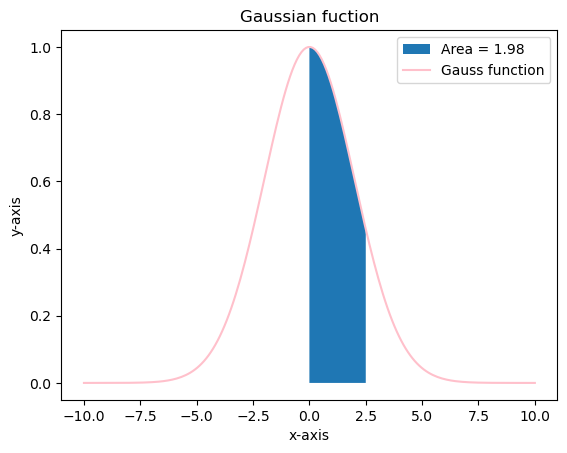

In [7]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as scp
    
A = 1.0
x0 = 0.0
sigma = 2.0
z0 = 0.0
x = np.linspace(-10, 10, 200)
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
y = gauss(x,A,x0,sigma,z0)

#integration
quadint_value, quadint_error =  scp.integrate.quad(gauss, 0, 2.5, args=(A, x0, sigma, z0))
print(f"The area from 0 to 2.5 is: {quadint_value:.3}")
quadint_value_inf, quadint_err_inf = scp.integrate.quad(gauss, -np.inf, np.inf, args=(A, x0, sigma, z0))
print(f"The area from -inf to inf is: {quadint_value_inf:.3}")
areafunc = A*sigma*(2*np.pi)**0.5
print(f"This is also equal to the function $A\sigma*\sqrt(2\pi)$ = {areafunc:0.3}")

#plot
xfill = np.linspace(0,2.5,100)
yfill = gauss(xfill,A,x0,sigma,z0)
plt.fill_between(xfill,yfill, label=f"Area = {quadint_value:.3}")

plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.title("Gaussian fuction")
plt.plot(x, y, linestyle='-', color="pink", label="Gauss function")
plt.legend()
plt.show()

enter a value for A:  1
enter a value for x0:  0
enter a value for sigma:  2
enter a value for z0:  0
enter a value for the lower boundary of intergration:  0
enter a value for the upper boundary of intergration:  2.5


The area from 0 to 2.5 is: 1.98


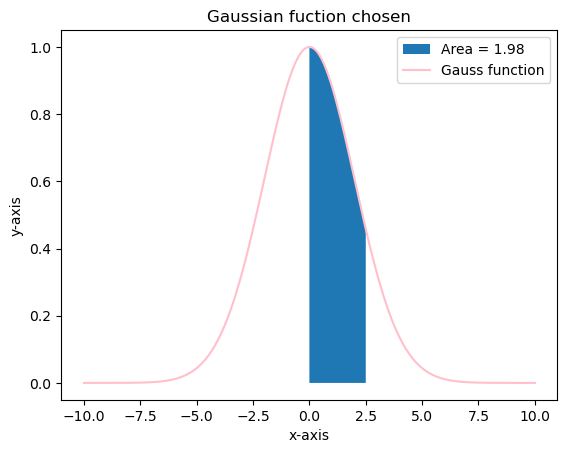

In [8]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as scp
    
A = eval(input("enter a value for A: "))
x0 = eval(input("enter a value for x0: "))
sigma = eval(input("enter a value for sigma: "))
z0 = eval(input("enter a value for z0: "))
intmin = eval(input("enter a value for the lower boundary of intergration: "))
intmax = eval(input("enter a value for the upper boundary of intergration: "))


x = np.linspace(-10, 10, 200)
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0       #The function for the gaussian distribution
y = gauss(x,A,x0,sigma,z0)

#integration
quadint_value, quadint_error =  scp.integrate.quad(gauss, intmin, intmax, args=(A, x0, sigma, z0))
print(f"The area from {intmin} to {intmax} is: {quadint_value:.3}")

#plot
xfill = np.linspace(intmin, intmax,200)
yfill = gauss(xfill,A,x0,sigma,z0)
plt.fill_between(xfill,yfill, label=f"Area = {quadint_value:.3}")
plt.xlabel("x-axis")
plt.ylabel("y-axis")
plt.title("Gaussian fuction chosen")


plt.plot(x, y, linestyle='-', color="pink", label="Gauss function")
plt.legend()
plt.show()

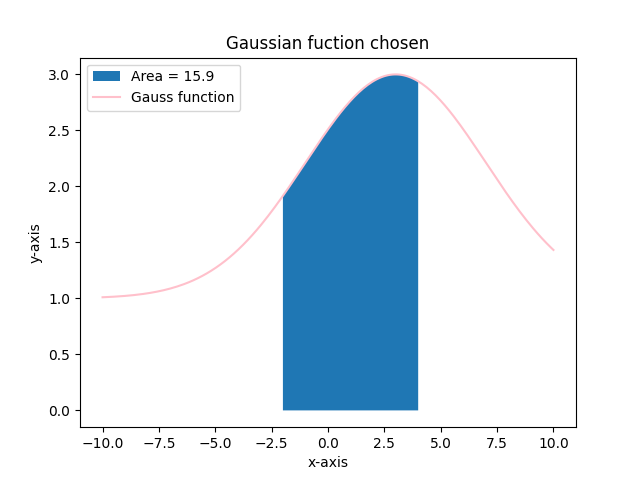

https://github.com/risinderen/PROGNUM-repo/blob/main/Task4/risinderen_S6446248_Gaussarea.py 

In [9]:
# Leave unaltered
totalpoints += 6
currentpoints += 5.5

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    Missing github link
</div>

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [ ]:
from numpy import sin, cos, exp, pi
import scipy
import numpy as np
x1 = eval(input("enter a value for the lower intergration boundary: "))
x2 = eval(input("enter a value for the upper intergration boundary: "))

try:
    x1 == 0
    x2 == 0

except:
    print("The chosen value of the lower boundary was not chosen to be 0")
    print("The chosen value of the upper boundary was not chosen to be pi")
    
else:
    if x1 == 0 and x2 == pi:
        def f(x):
            y = x**4 + exp(sin(x)+cos(x))
            return y
        integral_value, error = (scipy.integrate.quad(f,x1,x2))
        print(f"The intergral of f(x) from 0 to pi is: {integral_value}")

        xrandom = np.random.uniform(x1,x2, 100000)       #takes 100000 samples between the values of x1 and x2

        def intergral(xrandom):
            gral = ((x2-x1)/100000)*np.sum(xrandom**4 + exp(sin(xrandom)+cos(xrandom)))       #sums up the 100000 samples and does the thing what was said in the inbetween section
            return gral
        print(f"The monte carlo approximation of f(x) is: {intergral(xrandom)}")




In [11]:
x1 = 0
x1 == 1

False

In [12]:
# Leave unaltered
totalpoints += 6
currentpoints += 4

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    The function should be provided by the user
</div>

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

[ 2.7881622   1.5537195  -0.5254936  ...  0.9934931   0.05474758
  1.3610706 ]


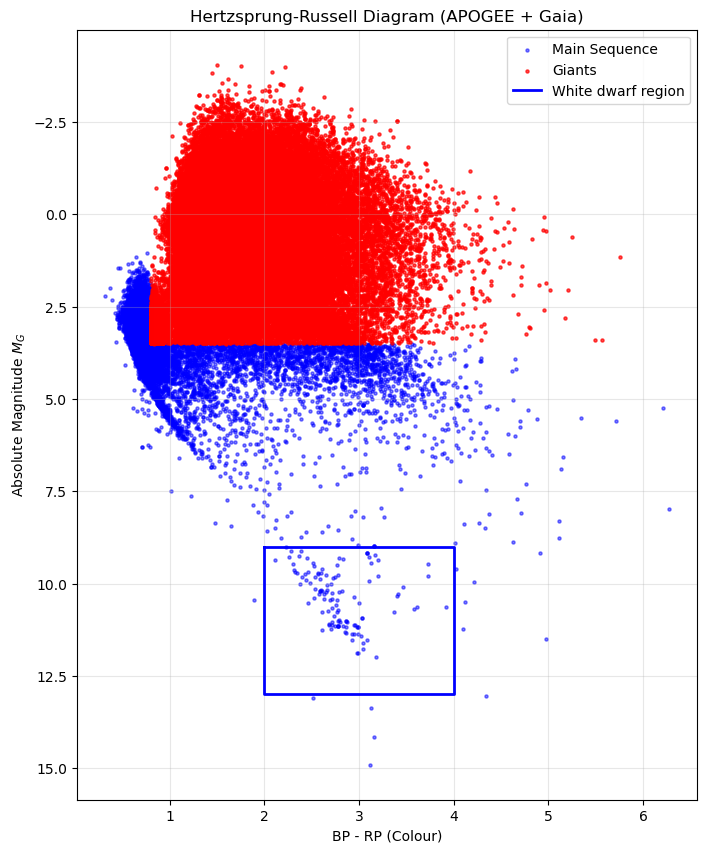

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Open FITS file
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data

# Extract relevant columns
parallax = data['GAIAEDR3_PARALLAX']
parallax_err = data['GAIAEDR3_PARALLAX_ERROR']
g_mag = data['GAIAEDR3_PHOT_G_MEAN_MAG']
bp_mag = data['GAIAEDR3_PHOT_BP_MEAN_MAG']
rp_mag = data['GAIAEDR3_PHOT_RP_MEAN_MAG']

# Apply quality criteria
mask = (
    (data['STARFLAG'] == 0) &
    (data['ASPCAPFLAG'] == 0) &
    (data['SNR'] > 10) &
    (parallax / parallax_err > 5) &
    np.isfinite(g_mag) &
    np.isfinite(bp_mag) &
    np.isfinite(rp_mag)
)

clean_data = data[mask]

# Randomly select 80% of the filtered data
np.random.seed(42)
rand_mask = np.random.rand(len(clean_data)) < 0.8
sample = clean_data[rand_mask]

# Extract columns again from sampled data
parallax = sample['GAIAEDR3_PARALLAX']
g_mag = sample['GAIAEDR3_PHOT_G_MEAN_MAG']
bp_mag = sample['GAIAEDR3_PHOT_BP_MEAN_MAG']
rp_mag = sample['GAIAEDR3_PHOT_RP_MEAN_MAG']

# Compute colour and absolute magnitude
color = bp_mag - rp_mag
MG = g_mag + 5 * np.log10(parallax / 1000) + 5
print(MG)

# Classify stars
giants = (MG < 3.5) & (color > 0.8)
main_sequence = ~giants

# Plot HR Diagram
plt.figure(figsize=(8,10))

plt.scatter(color[main_sequence], MG[main_sequence],
            s=5, color='blue', alpha=0.5, label='Main Sequence')

plt.scatter(color[giants], MG[giants],
            s=5, color='red', alpha=0.7, label='Giants')


plt.xlabel('BP - RP (Colour)')
plt.ylabel('Absolute Magnitude $M_G$')
plt.title('Hertzsprung-Russell Diagram (APOGEE + Gaia)')

# Invert magnitude axis (standard for HR diagrams)
plt.gca().invert_yaxis()

plt.plot([2,4,4,2,2], [9,9,13,13,9], color='blue', linewidth=2, label="White dwarf region")

plt.legend()
plt.grid(alpha=0.3)


plt.show()

In [14]:
# Leave unaltered
totalpoints += 6
currentpoints += 5

<div class='alert alert-warning'>
    <b>Feedback</b> <br>
    The white dwarf region should be specified
</div>

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [15]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 26. Student score: 21.5.  Task Grade = 8.3
